# Workshop Notebook: Predicting Critical Heat Flux (CHF) with LightGBM

Welcome to this hands-on machine learning workshop.

In this notebook, we will learn how to:
1. use Google Colab,
2. upload a dataset,
3. understand **features** and **target**,
4. train a **LightGBM regression model**,
5. evaluate the model using standard metrics,
6. visualize predictions and feature importance,
7. download the results.

---

## What is the engineering goal?

We want to predict **Critical Heat Flux (CHF)** in pool boiling using measurable thermo-physical and surface properties.

That means:
- the **inputs** are engineering properties such as pressure, roughness, and thermal conductivity,
- the **output** is the CHF value.

This is a **regression problem** because the target is a continuous number.

---

## What is LightGBM?

LightGBM stands for **Light Gradient Boosting Machine**.

It is a machine learning method based on many decision trees working together. It is often used because it can:
- learn nonlinear relationships,
- perform very well on tabular engineering datasets,
- train efficiently,
- estimate feature importance.

---

## Workshop style

This notebook is written for **complete beginners**.

Before each code section, you will see:
- what the code is doing,
- why that step matters,
- what you should look for in the output.

In [1]:
# Install only the extra packages we need for this workshop
# We do not force a specific scikit-learn version to avoid Colab dependency conflicts.

!pip -q install lightgbm shap openpyxl joblib

import warnings
warnings.filterwarnings("ignore")

import os
OUTPUT_DIR = "lightgbm_workshop_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Setup complete.")
print(f"All workshop outputs will be saved in: {OUTPUT_DIR}")

Setup complete.
All workshop outputs will be saved in: lightgbm_workshop_outputs


# Step 1 — Colab basics

Google Colab lets us write and run Python code in the browser.

A Colab notebook usually contains:
- **Text cells** for explanation,
- **Code cells** for running Python commands.

To run a code cell:
- click inside the cell,
- then press the **Run** button, or
- press **Shift + Enter**.

In this workshop, we will go step by step from data upload to final model results.

In [2]:
# Import the libraries used in this workshop

import json
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from IPython.display import display

from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from scipy.stats import randint, loguniform

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("Libraries imported successfully.")

Libraries imported successfully.


# Step 2 — Upload the dataset

Machine learning starts with data.

In this notebook, you will upload your CHF dataset directly from your computer. This makes the workflow easy for students using their own laptops.

The next cell will:
- open a file upload box,
- load a CSV or Excel file,
- show the first few rows.

---

## What should students observe?

After upload, look at:
- the number of rows and columns,
- the column names,
- whether the dataset appears properly arranged.

In [4]:
# Upload dataset from your computer

uploaded = files.upload()

filename = list(uploaded.keys())[0]
print(f"Uploaded file: {filename}")

if filename.lower().endswith(".csv"):
    df = pd.read_csv(filename)
elif filename.lower().endswith((".xlsx", ".xls")):
    df = pd.read_excel(filename)
else:
    raise ValueError("Unsupported file format. Please upload a CSV, XLSX, or XLS file.")

print("\nDataset loaded successfully.")
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

display(df.head())

Saving Dataset_AI_ML_Workshop.csv to Dataset_AI_ML_Workshop (1).csv
Uploaded file: Dataset_AI_ML_Workshop (1).csv

Dataset loaded successfully.
Dataset shape: 184 rows × 14 columns


,Author,base_material,substrate_material,substrate_thermal_conductivity_W_mK,operational_pressure_kPa,wall_superheat_K,saturated_temperature_C,roughness_Ra,working_fluid,fluid_thermal_conductivity_W_mK,contact_angle_deg,CHF_kW_m2,p_crit_kPa,reduced_pressure
0,Kim_2020,Aluminum AA1050,Aluminum AA1050,237.0,101.3,32.00,56.0,0.081081,FC-72,0.056,15.93,159.9,1380.0,0.073406
1,Kim_2020,Aluminum AA1050,Aluminum AA1050,237.0,101.3,25.90,56.0,0.144144,FC-72,0.056,12.83,164.3,1380.0,0.073406
2,Kim_2020,Aluminum AA1050,Aluminum AA1050,237.0,101.3,21.17,56.0,0.252252,FC-72,0.056,12.63,191.8,1380.0,0.073406
3,Kim_2020,Aluminum AA1050,Aluminum AA1050,237.0,101.3,21.51,56.0,0.333333,FC-72,0.056,14.31,220.1,1380.0,0.073406
4,Kim_2020,Aluminum AA1050,Aluminum AA1050,237.0,101.3,22.00,56.0,0.513514,FC-72,0.056,13.77,202.6,1380.0,0.073406


# Step 3 — Standardize the important column names

Engineering datasets often use different names for the same physical quantity.

To make the notebook easier to follow, we rename the main columns to short standard names.

We will use:
- `k_s`   → substrate thermal conductivity
- `P`     → pressure
- `T_sat` → saturated temperature
- `R_a`   → roughness
- `k_f`   → fluid thermal conductivity
- `qCHF`  → critical heat flux

---

## Machine learning language

The first five are the **features**.  
The last one is the **target**.

Features = input variables  
Target = output we want to predict

In [8]:
# Rename important columns to a consistent format

rename_map = {
    "ks": "k_s",
    "kf": "k_f",
    "Tsat": "T_sat",
    "Ra": "R_a",
    "CHF": "qCHF",
    "substrate_thermal_conductivity_W_mK": "k_s",
    "fluid_thermal_conductivity_W_mK": "k_f",
    "operational_pressure_kPa": "P",
    "saturated_temperature_C": "T_sat",
    "roughness_Ra": "R_a",
    "CHF_kW_m2": "qCHF"
}

df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

required_columns = ["k_s", "P", "T_sat", "R_a", "k_f", "qCHF"]
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(
        f"These required columns are missing from the uploaded file: {missing_columns}\n"
        f"Available columns are: {list(df.columns)}"
    )

print("All required columns are present.\n")

overview_df = pd.DataFrame({
    "Column": required_columns,
    "Data type": [str(df[col].dtype) for col in required_columns],
    "Missing values": [int(df[col].isna().sum()) for col in required_columns]
})

display(overview_df)
display(df[required_columns].head())

All required columns are present.



,Column,Data type,Missing values
0,k_s,float64,0
1,P,float64,0
2,T_sat,float64,0
3,R_a,float64,0
4,k_f,float64,0
5,qCHF,float64,0


,k_s,P,T_sat,R_a,k_f,qCHF
0,237.0,101.3,56.0,0.081081,0.056,159.9
1,237.0,101.3,56.0,0.144144,0.056,164.3
2,237.0,101.3,56.0,0.252252,0.056,191.8
3,237.0,101.3,56.0,0.333333,0.056,220.1
4,237.0,101.3,56.0,0.513514,0.056,202.6


# Step 4 — Separate inputs and output

Now we explicitly tell the model:
- which columns are the input features,
- which column is the output to predict.

This is the standard supervised learning setup.

In this notebook:
- inputs = five engineering properties
- output = CHF

In [9]:
# Define features and target

feature_columns = ["k_s", "P", "T_sat", "R_a", "k_f"]
target_column = "qCHF"

X = df[feature_columns].copy()
y = df[target_column].astype(float).copy()

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nFeature preview:")
display(X.head())

print("\nTarget preview:")
display(y.head())

Feature matrix shape: (184, 5)
Target vector shape: (184,)

Feature preview:


,k_s,P,T_sat,R_a,k_f
0,237.0,101.3,56.0,0.081081,0.056
1,237.0,101.3,56.0,0.144144,0.056
2,237.0,101.3,56.0,0.252252,0.056
3,237.0,101.3,56.0,0.333333,0.056
4,237.0,101.3,56.0,0.513514,0.056



Target preview:


,qCHF
0,159.9
1,164.3
2,191.8
3,220.1
4,202.6


# Step 5 — Train/test split

A good machine learning model should be tested on data it has never seen before.

So we divide the dataset into:
- **training set** → used to learn patterns
- **test set** → used to check final performance

In this notebook, we use:
- 80% for training
- 20% for testing

This helps us evaluate whether the model can generalize to new data.

In [12]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED
)

print("Train/test split completed.")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Train/test split completed.
Training samples: 147
Testing samples:  37


# Step 6 — Build the LightGBM model

We now create the LightGBM workflow.

This includes three useful ideas:

### 1. Missing-value handling
Real data can contain empty cells, so we use a **median imputer**.

### 2. Hyperparameter tuning
Machine learning models have settings such as:
- learning rate,
- number of trees,
- number of leaves,
- maximum depth.

We let the computer test several combinations using **RandomizedSearchCV**.

### 3. Cross-validation
Cross-validation means the model is trained and checked multiple times on different portions of the training data, which gives a more reliable estimate.

---

## Practical note

For tree-based models like LightGBM, feature scaling is usually not necessary.

In [13]:
# Build a beginner-friendly LightGBM pipeline and tune it using randomized search

lgbm_model = LGBMRegressor(
    objective="regression",
    boosting_type="gbdt",
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", lgbm_model)
])

param_distributions = {
    "model__learning_rate": [0.08, 0.10, 0.12, 0.14, 0.17, 0.20],
    "model__n_estimators": [300, 500, 800, 1200, 1600],
    "model__num_leaves": randint(15, 80),
    "model__min_child_samples": [3, 5, 7, 10, 20, 30],
    "model__min_split_gain": [0.0, 0.01, 0.05, 0.10],
    "model__feature_fraction": [0.6, 0.8, 0.9, 1.0],
    "model__bagging_fraction": [0.6, 0.8, 0.9, 1.0],
    "model__bagging_freq": [0, 1],
    "model__reg_alpha": loguniform(1e-4, 1.0),
    "model__reg_lambda": loguniform(1e-3, 10.0),
    "model__max_bin": [63, 127, 255],
    "model__boost_from_average": [True, False],
    "model__max_depth": [-1, 5, 7, 9, 11, 13]
}

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=20,   # reduced for workshop speed
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    random_state=SEED,
    verbose=1,
    refit=True
)

search.fit(X_train, y_train)

best_pipe = search.best_estimator_

print("\nBest hyperparameters found:")
for k, v in search.best_params_.items():
    print(f"{k}: {v}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best hyperparameters found:
model__bagging_fraction: 0.6
model__bagging_freq: 0
model__boost_from_average: False
model__feature_fraction: 0.8
model__learning_rate: 0.17
model__max_bin: 127
model__max_depth: 13
model__min_child_samples: 10
model__min_split_gain: 0.05
model__n_estimators: 800
model__num_leaves: 70
model__reg_alpha: 0.0008923807143379785
model__reg_lambda: 0.8182111518618421


# Step 7 — Evaluate the model

Now we test the trained model on unseen data.

We will calculate three standard regression metrics:

### RMSE
Root Mean Squared Error  
Lower is better

### MAE
Mean Absolute Error  
Lower is better

### R²
Coefficient of determination  
Closer to 1 is better

These help us judge how close the model predictions are to the true CHF values.

In [14]:
# Predict on the test set and calculate performance metrics

y_pred = best_pipe.predict(X_test)

rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
mae = float(mean_absolute_error(y_test, y_pred))
r2 = float(r2_score(y_test, y_pred))

summary_table = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R²"],
    "Value": [rmse, mae, r2]
})

print("Model performance on the test set:\n")
display(summary_table)

summary_table.to_csv(os.path.join(OUTPUT_DIR, "lightgbm_metrics_summary.csv"), index=False)

Model performance on the test set:



,Metric,Value
0,RMSE,194.359228
1,MAE,137.351776
2,R²,0.934312


# Step 8 — Compare predicted CHF with actual CHF

A very useful plot in regression is the **parity plot**.

In this plot:
- each point is one test sample,
- the dashed red line is the ideal 1:1 line.

If the points lie close to the red line, the predictions are good.

We will also make a residual plot.

Residual = Actual − Predicted

Residual plots help us see whether the model is making any systematic errors.

In [15]:
# Helper function to save figures

def save_current_figure(filename):
    full_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(full_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {full_path}")

Saved: lightgbm_workshop_outputs/lightgbm_predicted_vs_actual.jpg


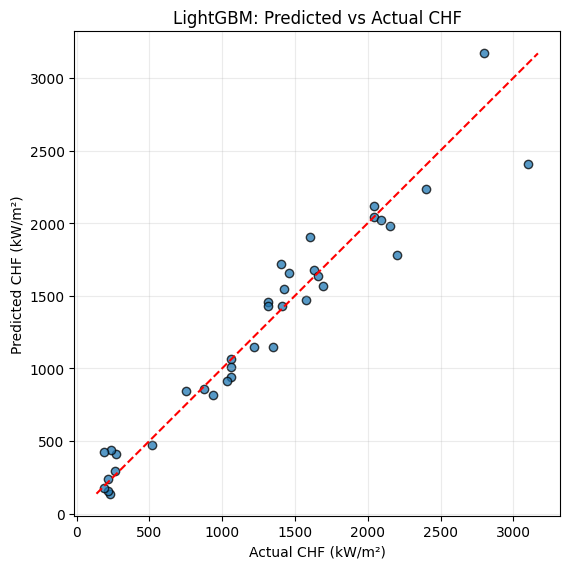

In [16]:
# Parity plot: Actual vs Predicted CHF

plt.figure(figsize=(5.8, 5.8))
plt.scatter(y_test, y_pred, alpha=0.75, edgecolor="black")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5)

plt.xlabel("Actual CHF (kW/m²)")
plt.ylabel("Predicted CHF (kW/m²)")
plt.title("LightGBM: Predicted vs Actual CHF")
plt.grid(alpha=0.25)
plt.tight_layout()

save_current_figure("lightgbm_predicted_vs_actual.jpg")
plt.show()

Saved: lightgbm_workshop_outputs/lightgbm_predicted_vs_actual.jpg


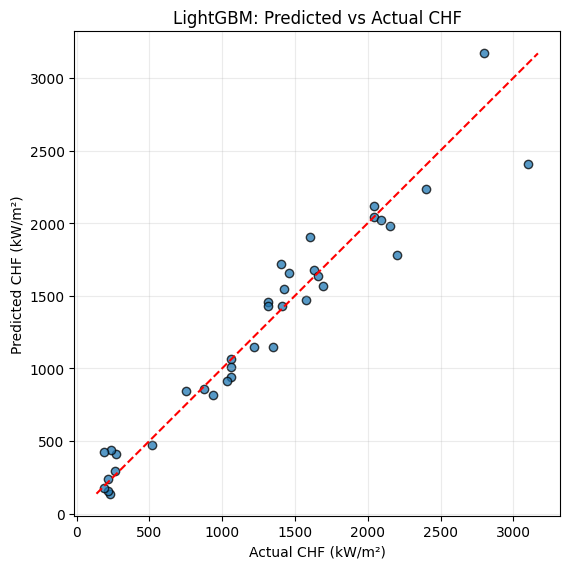

In [17]:
# Parity plot: Actual vs Predicted CHF

plt.figure(figsize=(5.8, 5.8))
plt.scatter(y_test, y_pred, alpha=0.75, edgecolor="black")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5)

plt.xlabel("Actual CHF (kW/m²)")
plt.ylabel("Predicted CHF (kW/m²)")
plt.title("LightGBM: Predicted vs Actual CHF")
plt.grid(alpha=0.25)
plt.tight_layout()

save_current_figure("lightgbm_predicted_vs_actual.jpg")
plt.show()

# Step 9 — Which features matter most?

LightGBM can estimate feature importance.

This tells us which input variables were most useful to the model during training.

This does not replace physical reasoning, but it is a very useful model interpretation tool.

Feature importance table:



,Feature,Importance
3,R_a,3744
0,k_s,1447
2,T_sat,935
4,k_f,918
1,P,653


Saved: lightgbm_workshop_outputs/lightgbm_feature_importance.jpg


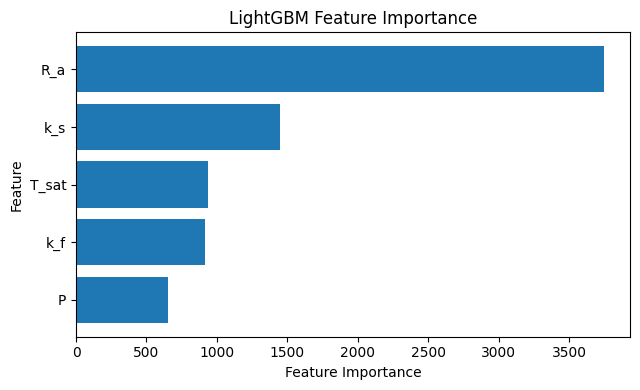

In [18]:
# Feature importance plot

trained_model = best_pipe.named_steps["model"]

importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": trained_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("Feature importance table:\n")
display(importance_df)

plt.figure(figsize=(6.5, 4.0))
plt.barh(
    importance_df["Feature"][::-1],
    importance_df["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("LightGBM Feature Importance")
plt.tight_layout()

save_current_figure("lightgbm_feature_importance.jpg")
plt.show()

# Step 10 — Optional model interpretation with SHAP

This section is optional.

SHAP helps explain:
- which features pushed a prediction upward,
- which features pushed it downward,
- how strong each feature’s influence was.

For a beginner workshop, this is a good advanced section after the main modeling steps are complete.

If time is short, this part can be skipped.

Saved: lightgbm_workshop_outputs/shap_global_importance_bar_lgbm.jpg


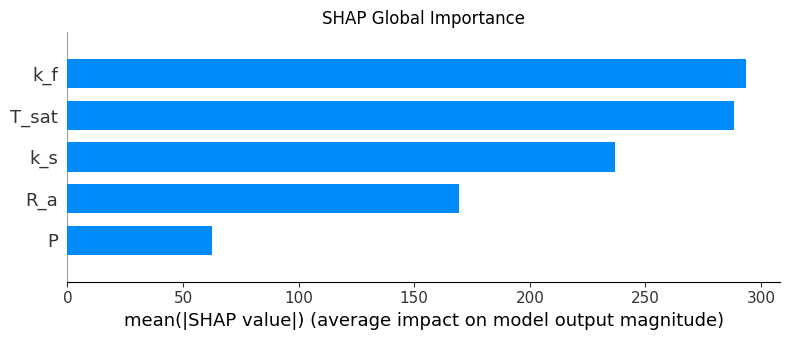

Saved: lightgbm_workshop_outputs/shap_beeswarm_lgbm.jpg


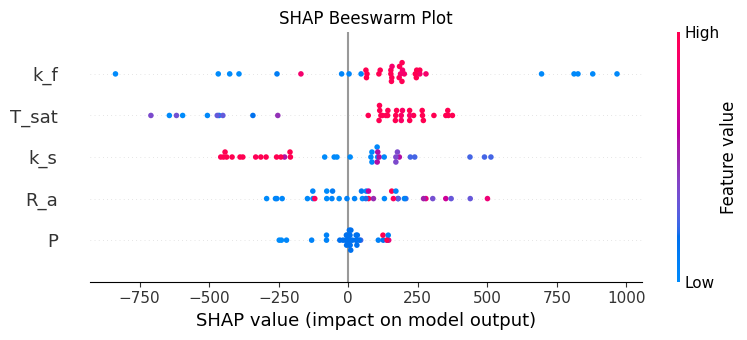

In [19]:
# Optional SHAP analysis

import shap

imputer = best_pipe.named_steps["imputer"]
trained_model = best_pipe.named_steps["model"]

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=feature_columns
)

# Build SHAP explainer
try:
    explainer = shap.TreeExplainer(trained_model)
    shap_output = explainer(X_test_imputed)
    shap_values = shap_output.values if hasattr(shap_output, "values") else shap_output
except Exception:
    explainer = shap.Explainer(trained_model, X_test_imputed)
    shap_output = explainer(X_test_imputed)
    shap_values = shap_output.values

# SHAP bar plot
plt.figure(figsize=(7, 4))
shap.summary_plot(shap_values, X_test_imputed, plot_type="bar", show=False)
plt.title("SHAP Global Importance")
plt.tight_layout()
save_current_figure("shap_global_importance_bar_lgbm.jpg")
plt.show()

# SHAP beeswarm plot
plt.figure(figsize=(7, 4))
shap.summary_plot(shap_values, X_test_imputed, show=False)
plt.title("SHAP Beeswarm Plot")
plt.tight_layout()
save_current_figure("shap_beeswarm_lgbm.jpg")
plt.show()

# Step 11 — Optional hyperparameter sensitivity

Machine learning models are sensitive to their settings.

This section helps students see how model performance changes with:
- learning rate,
- maximum depth.

This is useful because it connects:
- model tuning,
- cross-validation,
- engineering judgment.

Saved: lightgbm_workshop_outputs/learning_rate_sensitivity_lgbm.jpg


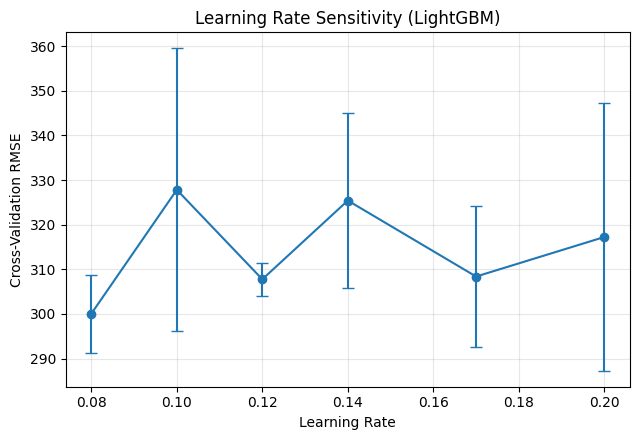

Saved: lightgbm_workshop_outputs/max_depth_sensitivity_lgbm.jpg


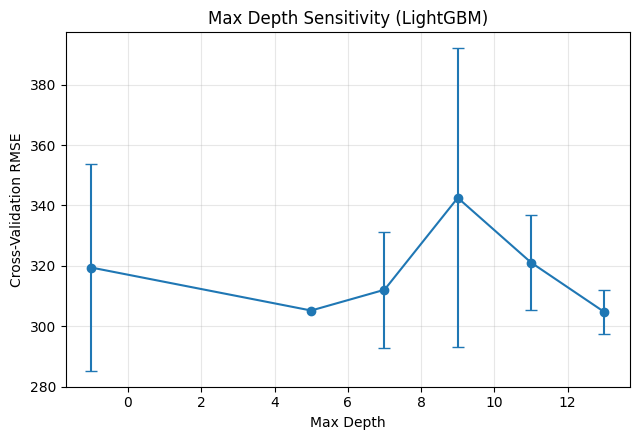

In [20]:
# Hyperparameter sensitivity plots using CV results

cv_results = pd.DataFrame(search.cv_results_)

results_df = pd.DataFrame({
    "mean_test_score": cv_results["mean_test_score"],
    "std_test_score": cv_results["std_test_score"],
    "learning_rate": cv_results["param_model__learning_rate"],
    "max_depth": cv_results["param_model__max_depth"]
})

results_df["mean_RMSE"] = -results_df["mean_test_score"]

lr_group = results_df.groupby("learning_rate", as_index=False).agg(
    mean_RMSE=("mean_RMSE", "mean"),
    std_RMSE=("mean_RMSE", "std")
)

depth_group = results_df.groupby("max_depth", as_index=False).agg(
    mean_RMSE=("mean_RMSE", "mean"),
    std_RMSE=("mean_RMSE", "std")
)

# Learning rate sensitivity
plt.figure(figsize=(6.5, 4.5))
plt.errorbar(
    lr_group["learning_rate"],
    lr_group["mean_RMSE"],
    yerr=lr_group["std_RMSE"],
    fmt="-o",
    capsize=4
)
plt.xlabel("Learning Rate")
plt.ylabel("Cross-Validation RMSE")
plt.title("Learning Rate Sensitivity (LightGBM)")
plt.grid(alpha=0.3)
plt.tight_layout()
save_current_figure("learning_rate_sensitivity_lgbm.jpg")
plt.show()

# Max depth sensitivity
plt.figure(figsize=(6.5, 4.5))
plt.errorbar(
    depth_group["max_depth"],
    depth_group["mean_RMSE"],
    yerr=depth_group["std_RMSE"],
    fmt="-o",
    capsize=4
)
plt.xlabel("Max Depth")
plt.ylabel("Cross-Validation RMSE")
plt.title("Max Depth Sensitivity (LightGBM)")
plt.grid(alpha=0.3)
plt.tight_layout()
save_current_figure("max_depth_sensitivity_lgbm.jpg")
plt.show()

# Step 12 — Save and download the final results

A good scientific workflow should save:
- the performance metrics,
- the model predictions,
- the best hyperparameters,
- the figures.

The next cell will:
1. save a test prediction table,
2. save the best model settings,
3. create a zip file,
4. download the zip file to your computer.

In [21]:
# Save final tables and download everything as a zip file

predictions_df = X_test.copy()
predictions_df["Actual_qCHF"] = y_test.values
predictions_df["Predicted_qCHF"] = y_pred
predictions_df["Residual"] = y_test.values - y_pred

predictions_path = os.path.join(OUTPUT_DIR, "lightgbm_test_predictions.csv")
predictions_df.to_csv(predictions_path, index=False)

best_params_clean = {}
for k, v in search.best_params_.items():
    key = k.replace("model__", "")
    if isinstance(v, (np.integer,)):
        best_params_clean[key] = int(v)
    elif isinstance(v, (np.floating,)):
        best_params_clean[key] = float(v)
    else:
        best_params_clean[key] = v

params_path = os.path.join(OUTPUT_DIR, "best_lightgbm_params.json")
with open(params_path, "w") as f:
    json.dump(best_params_clean, f, indent=2)

zip_path = shutil.make_archive("lightgbm_workshop_results", "zip", OUTPUT_DIR)

print("Saved files:")
print(f"- {predictions_path}")
print(f"- {params_path}")
print(f"- {zip_path}")

files.download(zip_path)

Saved files:
- lightgbm_workshop_outputs/lightgbm_test_predictions.csv
- lightgbm_workshop_outputs/best_lightgbm_params.json
- /content/lightgbm_workshop_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Final reflection

By this point, you have completed a full beginner-friendly machine learning workflow using LightGBM:

- uploaded an engineering dataset,
- identified features and target,
- split the data into training and testing sets,
- trained a LightGBM regression model,
- evaluated its performance,
- visualized predictions,
- interpreted feature importance,
- optionally explored SHAP and hyperparameter sensitivity,
- downloaded the final outputs.

This is a complete example of how machine learning can be applied to thermal engineering research.